Our aim with this file is to HELP someone establish how initial parameters were chosen for the box size – this CAN come after the the cross section in the dissertation

In [ ]:
# cd "/storage/home/hcoda1/9/pagrawala6/r-js130-0/1_add_more_fingers/"

In [2]:
# ls -lh

In [1]:
import duckdb
import numpy as np
import pandas as pd
conn11 = duckdb.connect("/storage/home/hcoda1/9/pagrawala6/r-js130-0/1_add_more_fingers/11/duo_oxygen1616_schumannrunge_corrected2.duckdb")
conn10 = duckdb.connect("/storage/home/hcoda1/9/pagrawala6/r-js130-0/1_add_more_fingers/10/duo_oxygen1616_schumannrunge_corrected2.duckdb")
conn9 = duckdb.connect("/storage/home/hcoda1/9/pagrawala6/r-js130-0/1_add_more_fingers/9/duo_oxygen1616_schumannrunge_corrected2.duckdb")


[9Å] Number of transitions (60000–61000 cm^-1): 427559
[10Å] Number of transitions (60000–61000 cm^-1): 480519
[11Å] Number of transitions (60000–61000 cm^-1): 533824


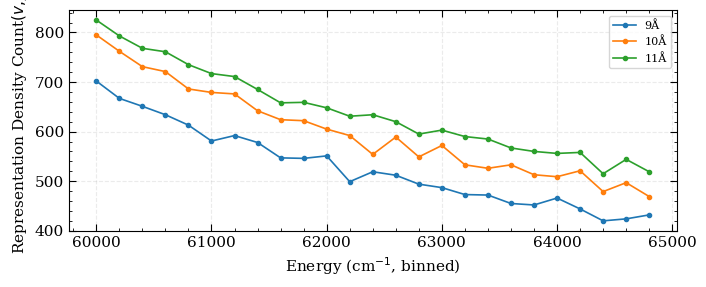

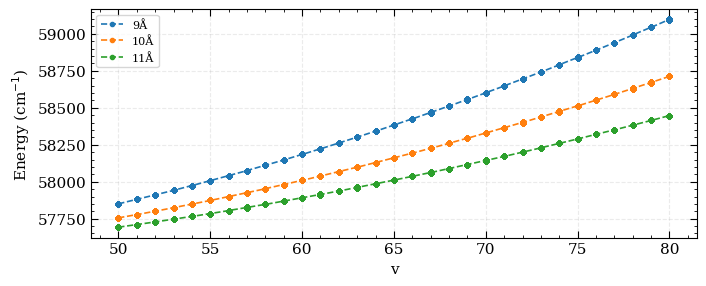

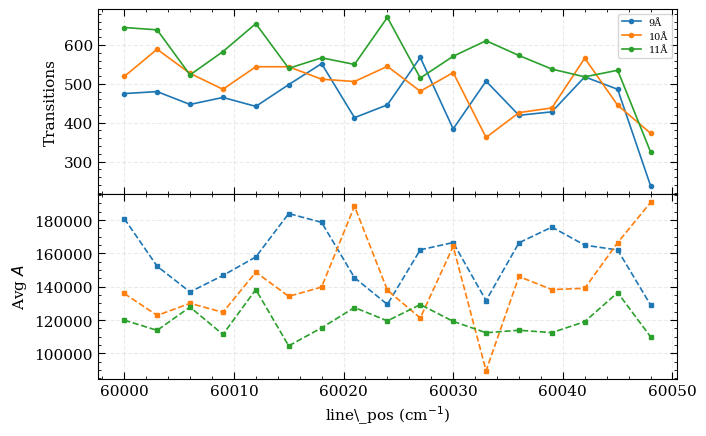

In [28]:
from matplotlib import colors
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ──────────────────────────────────────────────
# Global style (uniform)
# ──────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
})

FIGSIZE = (7.2, 3.0)
LW = 1.2
MS = 3

conns = [conn9, conn10, conn11]
labels = ["9Å", "10Å", "11Å"]
colors = ["tab:blue", "tab:orange", "tab:green"]

# ──────────────────────────────────────────────
# 1) Count transitions
# ──────────────────────────────────────────────
for conn, label in zip(conns, labels):
    num_transitions = conn.execute(
        """
        SELECT COUNT(*) AS num_transitions
        FROM duo_oxygen1616_schumannrunge
        WHERE up_energy BETWEEN 60000 AND 61000
        """
    ).df().iloc[0, 0]
    print(f"[{label}] Number of transitions (60000–61000 cm^-1): {num_transitions}")


# ──────────────────────────────────────────────
# Common axis styling function
# ──────────────────────────────────────────────
def style_axes(ax):
    ax.tick_params(which='major', direction='in', length=5, top=True, right=True)
    ax.tick_params(which='minor', direction='in', length=2.5, top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(True, ls="--", alpha=0.25)


# ──────────────────────────────────────────────
# 2) (v,J) vs energy
# ──────────────────────────────────────────────
bin_size_E = 200.0

fig, ax = plt.subplots(figsize=FIGSIZE)

for conn, label, color in zip(conns, labels, colors):
    df = conn.execute(
        """
        SELECT up_energy, up_v, up_J
        FROM duo_oxygen1616_schumannrunge
        WHERE up_energy BETWEEN 60000 AND 65000
        """
    ).df()

    df["energy_bin"] = (df["up_energy"] // bin_size_E) * bin_size_E

    grouped = df.groupby(["energy_bin", "up_v", "up_J"]).size().reset_index()
    counts = grouped.groupby("energy_bin").size().reset_index(name="num_levels")

    ax.plot(counts["energy_bin"], counts["num_levels"],
            "-", marker="o", ms=MS, lw=LW, color=color, label=label)

ax.set_xlabel(r"Energy (cm$^{-1}$, binned)")
ax.set_ylabel(r"Representation Density Count$(v,J)$")
ax.legend(frameon=True, fontsize=8)

style_axes(ax)
plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────
# 3) Energy vs v
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE)

for conn, label, color in zip(conns, labels, colors):
    df = conn.execute(
        """
        SELECT up_v, up_energy
        FROM duo_oxygen1616_schumannrunge
        WHERE up_J = 1 AND up_v BETWEEN 50 AND 80
        """
    ).df().sort_values("up_v")

    ax.plot(df["up_v"], df["up_energy"],
            "--", marker="o", ms=MS, lw=LW, color=color, label=label)

ax.set_xlabel("v")
ax.set_ylabel(r"Energy (cm$^{-1}$)")
ax.legend(frameon=True, fontsize=8)

style_axes(ax)
plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────
# 4) Combined (counts + A) SAME FIG SIZE
# ──────────────────────────────────────────────
bin_size = 3.0

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(FIGSIZE[0], FIGSIZE[1]*1.5),
    sharex=True,
    gridspec_kw={"hspace": 0.0}
)

# --- Counts ---
for conn, label, color in zip(conns, labels, colors):
    df = conn.execute(f"""
        SELECT FLOOR(line_pos/{bin_size}) * {bin_size} AS energy_bin,
               COUNT(*) AS row_count
        FROM duo_oxygen1616_schumannrunge
        WHERE line_pos BETWEEN 60000 AND 60050
        GROUP BY energy_bin
        ORDER BY energy_bin
    """).df()

    ax1.plot(df["energy_bin"], df["row_count"],
             "-", marker="o", ms=MS, lw=LW, color=color, label=label)

ax1.set_ylabel("Transitions")
ax1.legend(frameon=True, fontsize=7)
style_axes(ax1)

# --- Einstein A ---
for conn, label, color in zip(conns, labels, colors):
    df = conn.execute(f"""
        SELECT FLOOR(line_pos/{bin_size}) * {bin_size} AS energy_bin,
               AVG(A) AS avg_Einstein_A
        FROM duo_oxygen1616_schumannrunge
        WHERE line_pos BETWEEN 60000 AND 60050
        GROUP BY energy_bin
        ORDER BY energy_bin
    """).df()

    ax2.plot(df["energy_bin"], df["avg_Einstein_A"],
             "--", marker="s", ms=MS, lw=LW, color=color)

ax2.set_xlabel(r"line\_pos (cm$^{-1}$)")
ax2.set_ylabel(r"Avg $A$")

style_axes(ax2)

plt.tight_layout()
plt.show()


This helps us see inverse nature of density of an energy region and Einstein A: since not that much smoothing is required, the aerage A21 is a lot lower


In [22]:
# Parallel computation of the cross-section
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import threading
from typing import Tuple, List
import time
c = 2.99792458e10  # speed of light in cm/s
h = 6.62607015e-34  # Planck's constant in J*s
k_B = 1.380649e-23  # Boltzmann's constant in J/K

T = 300  # Temperature in Kelvin
Q_T = 219.1532829847414  # Partition function at temperature T


def gaussian_lineprofile(nu, nu_nominal, alpha_D):
    """Compute Gaussian line profile"""
    return np.sqrt(np.log(2)/np.pi) * (1/alpha_D) * np.exp(-np.log(2) * (nu - nu_nominal)**2 / alpha_D**2)

def process_transition_chunk_vectorized(args):
    """
    Process a chunk of transitions using vectorized operations with frequency masking
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_D, thread_id = args
    
    # Initialize local cross-section array
    local_cross_section = np.zeros_like(nu_range)
    cutoff_range = 4 * alpha_D
    
    # Vectorized computation for this chunk
    # Create 2D arrays: (n_transitions, n_frequencies)
    nu_grid = nu_range[np.newaxis, :]  # Shape: (1, n_freq)
    pos_grid = line_positions[:, np.newaxis]  # Shape: (n_trans, 1)
    
    # Apply frequency masking: only compute within cutoff range
    mask = np.abs(nu_grid - pos_grid) <= cutoff_range
    
    # Compute Gaussian contributions only where mask is True
    distances = nu_grid - pos_grid
    gaussians = np.zeros_like(distances)
    
    # Only compute Gaussian where mask is True (keeps your masking logic)
    gaussians[mask] = (np.sqrt(np.log(2)/np.pi) * (1/alpha_D) * 
                      np.exp(-np.log(2) * distances[mask]**2 / alpha_D**2))
    
    # Weight by intensities and sum along transition axis
    weighted = gaussians * intensities[:, np.newaxis]
    local_cross_section = np.sum(weighted, axis=0)
    
    return local_cross_section

def process_transition_chunk(args):
    """
    Process a chunk of transitions with frequency masking and accumulate contributions
    
    Args:
        args: tuple containing (line_positions, intensities, nu_range, alpha_D, thread_id)
    
    Returns:
        numpy array with accumulated cross-section contributions
    """
    line_positions, intensities, nu_range, alpha_D, thread_id = args
    
    # Initialize local cross-section array
    local_cross_section = np.zeros_like(nu_range)
    
    # Process each transition in this chunk
    for central_position, intensity in zip(line_positions, intensities):
        # Apply frequency masking: only compute within 5 Doppler widths
        cutoff_range = 5 * alpha_D
        mask = (nu_range >= central_position - cutoff_range) & (nu_range <= central_position + cutoff_range)
        
            
        # Compute Gaussian contribution only for masked region
        masked_nu = nu_range[mask]
        contribution = intensity * gaussian_lineprofile(masked_nu, central_position, alpha_D)
        
        # Add contribution to local cross-section
        local_cross_section[mask] += contribution
    
    return local_cross_section

def compute_cross_section_optimized(line_positions, intensities, nu_range, alpha_D, 
                                  num_chunks=4, num_threads=None):
    """
    Compute cross-section using chunking and multithreading with frequency masking
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D: Doppler width parameter
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section: final cross-section array
    """
    total_transitions = len(line_positions)
    # print(f"Processing {total_transitions:,} transitions in {num_chunks} chunks")
    
    # Initialize final cross-section array
    cross_section = np.zeros_like(nu_range)
    
    # Calculate chunk size
    chunk_size = total_transitions // num_chunks
    
    # Process each chunk
    for chunk_idx in range(num_chunks):
        start_idx = chunk_idx * chunk_size
        if chunk_idx == num_chunks - 1:  # Last chunk gets remaining transitions
            end_idx = total_transitions
        else:
            end_idx = (chunk_idx + 1) * chunk_size
        
        chunk_line_positions = line_positions[start_idx:end_idx]
        chunk_intensities = intensities[start_idx:end_idx]
        
        # print(f"Processing chunk {chunk_idx + 1}/{num_chunks} "
        #       f"({len(chunk_line_positions):,} transitions)")
        
        # Further divide chunk for multithreading
        if num_threads is None:
            import os
            num_threads = os.cpu_count()
        
        thread_chunk_size = len(chunk_line_positions) // num_threads
        thread_args = []
        
        for thread_idx in range(num_threads):
            thread_start = thread_idx * thread_chunk_size
            if thread_idx == num_threads - 1:  # Last thread gets remaining
                thread_end = len(chunk_line_positions)
            else:
                thread_end = (thread_idx + 1) * thread_chunk_size
            
            if thread_start < len(chunk_line_positions):
                thread_args.append((
                    chunk_line_positions[thread_start:thread_end],
                    chunk_intensities[thread_start:thread_end],
                    nu_range,
                    alpha_D,
                    thread_idx
                ))
        
        # Execute multithreaded computation for this chunk
        start_time = time.time()
        with ThreadPoolExecutor(max_workers=num_threads) as executor:
            results = list(executor.map(process_transition_chunk_vectorized, thread_args))
        
        # Accumulate results from all threads
        for result in results:
            cross_section += result
        
        chunk_time = time.time() - start_time
        # print(f"Chunk {chunk_idx + 1} completed in {chunk_time:.2f}s")
    
    return cross_section

def compute_cross_section_batch_optimized(line_positions, intensities, nu_range, alpha_D_list, 
                                        num_chunks=4, num_threads=None):
    """
    Compute cross-sections for multiple alpha_D values using optimized approach
    
    Args:
        line_positions: array of transition frequencies
        intensities: array of transition intensities
        nu_range: frequency grid for final spectrum
        alpha_D_list: list of Doppler width parameters
        num_chunks: number of chunks to divide transitions into
        num_threads: number of threads per chunk (None = auto)
    
    Returns:
        cross_section_list: list of cross-section arrays
    """
    cross_section_list = []
    
    for i, alpha_D in enumerate(alpha_D_list):
        # print(f"\nProcessing alpha_D = {alpha_D} ({i+1}/{len(alpha_D_list)})")
        start_time = time.time()
        
        cross_section = compute_cross_section_optimized(
            line_positions, intensities, nu_range, alpha_D, 
            num_chunks, num_threads
        )
        
        cross_section_list.append(cross_section)
        
        total_time = time.time() - start_time
        # print(f"Alpha_D = {alpha_D} completed in {total_time:.2f}s")
    
    return cross_section_list


import requests
import numpy as np
import matplotlib.pyplot as plt
import io

def plot_exomol_o2_cross_section(temperature):
    """
    Fetches, parses, and plots O2 photodissociation cross-sections
    from ExoMol for a given temperature.
    """
    # 1. Construct the URL for the desired temperature
    url = f"https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__{temperature}__0__0.1.photo"
    print(f"Fetching data for T = {temperature} K from {url}")

    try:
        # 2. Fetch the data
        response = requests.get(url)
        response.raise_for_status()  # Raises an exception for bad status codes (404, 500, etc.)

        # 3. Use io.StringIO to treat the text content as a file in memory
        #    The data is whitespace-delimited.
        data_file = io.StringIO(response.text)

        # 4. Load the data directly into NumPy arrays
        #    The first column is wavelength (nm), the second is cross-section (cm^2)
        wavelength, cross_section = np.loadtxt(data_file, unpack=True)
        
        # 5. Plot for validation
        # plt.style.use('seaborn-v0_8-whitegrid')
        # fig, ax = plt.subplots(figsize=(10, 6))

        # ax.plot(wavelength, cross_section)

        # ax.set_xlabel('Wavelength (nm)')
        # ax.set_ylabel(r'Cross Section ($cm^{2} \, molecule^{-1}$)')
        # ax.set_title('Absorption Cross Section vs Wavelength (T = 3000 K)')
        # ax.grid(True, which="both", ls="--")
        # ax.set_xlim(130, 180)
        # ax.set_ylim(1e-20, 0.5e-16)
        # ax.set_yscale('log') # Cross-sections often span many orders of magnitude

        # plt.show()
        return wavelength, cross_section

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage with your data
def main(alpha_D_list, nu_range, line_positions, intensities, num_chunks =4):
    # Set up frequency range
    
    
    n_transitions = len (intensities)  # 14 million transitions
    
    print(f"Starting computation with {len(line_positions):,} transitions")
    print(f"Frequency range: {nu_range.min():.1f} to {nu_range.max():.1f} cm⁻¹")
    print(f"Alpha_D values: {alpha_D_list}")
    
    # Run optimized computation
    start_time = time.time()
    cross_section_list = compute_cross_section_batch_optimized(
        line_positions, intensities, nu_range, alpha_D_list,
        num_chunks, num_threads=None  # Auto-detect thread count
    )
    
    total_time = time.time() - start_time
    print(f"\nTotal computation time: {total_time:.2f}s")
    print(f"Cross-section shapes: {[cs.shape for cs in cross_section_list]}")
    
    return cross_section_list




# --- Run the function for a specific temperature ---
plot_exomol_o2_cross_section(temperature=3000)

Fetching data for T = 3000 K from https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__3000__0__0.1.photo


(array([ 50. ,  50.1,  50.2, ..., 499.8, 499.9, 500. ]),
 array([2.19e-22, 2.00e-22, 1.84e-22, ..., 2.65e-25, 2.66e-25, 2.68e-25]))

Starting computation with 671,857 transitions
Frequency range: 60000.0 to 65000.0 cm⁻¹
Alpha_D values: [1, 100]

Total computation time: 6.14s
Cross-section shapes: [(5000,), (5000,)]
[9Å] Integrated cross-section α_D=1: 1.8286e-14
[9Å] Integrated cross-section α_D=100: 1.8009e-14
Starting computation with 837,982 transitions
Frequency range: 60000.0 to 65000.0 cm⁻¹
Alpha_D values: [1, 100]

Total computation time: 7.69s
Cross-section shapes: [(5000,), (5000,)]
[11Å] Integrated cross-section α_D=1: 1.8268e-14
[11Å] Integrated cross-section α_D=100: 1.7999e-14
Fetching data for T = 300 K from https://www.exomol.com/db/O2/16O2/PhoMol/16O2__PhoMol__50.0-500.0__300__0__0.1.photo


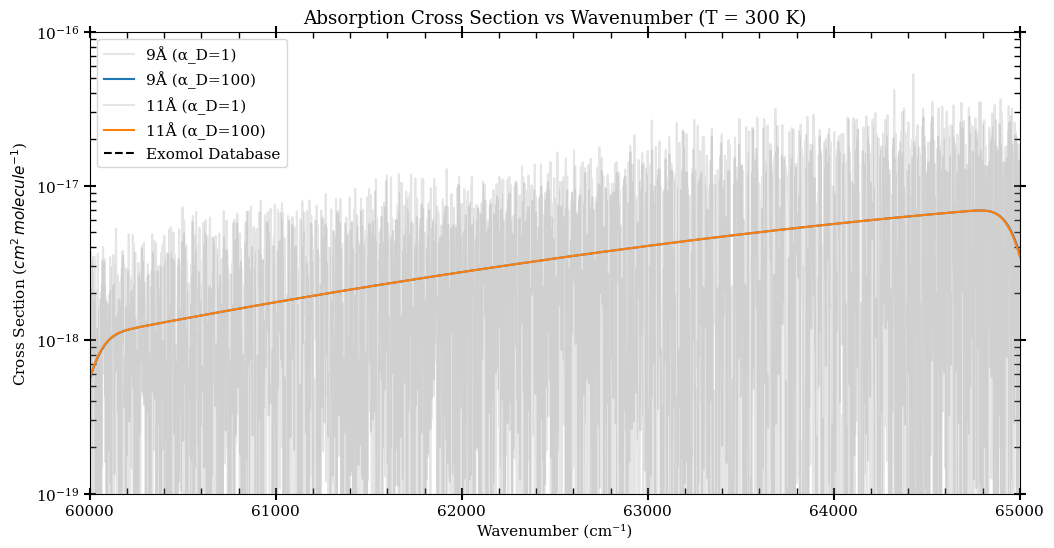

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

bin_low, bin_high = 60000, 65000  # cm^-1 window for line_pos

# === Loop over conns ===
fig, ax = plt.subplots(figsize=(12, 6))

for conn, label in zip(conns, labels):
    if not label == "10Å":
          # Skip the 10Å dataset for this analysis

        # 1. Pull continuum transitions in the restricted range
        continuum = conn.execute(f"""
            SELECT *
            FROM duo_oxygen1616_schumannrunge
            WHERE down_energy < 42025
            AND line_pos BETWEEN {bin_low} AND {bin_high}
        """).df()

        # 2. Group by quantum numbers (if needed later)
        continuum_grouped = continuum.groupby(
            ['down_v', 'down_J', 'down_lambda', 'down_sigma', 'down_omega', 'down_energy']
        ).agg({
            'A': list,
            'line_pos': list,
            'up_energy': list,
            'up_J': list
        }).reset_index()

        # 3. Compute intensities
        continuum['Intensity'] = continuum['A'] * (2 * continuum['up_J'] + 1) * np.exp(
            -(h * c * continuum['down_energy'] / (k_B * T))
        ) / (8.0 * np.pi * c * continuum['line_pos']**2 * Q_T)

        # 4. Sort and extract arrays
        df = continuum.sort_values(by='line_pos', ascending=True)
        line_positions = df['line_pos'].values
        intensities = df['Intensity'].values

        # 5. Cross section calculation
        alpha_D_list = [1, 100]   # adapt as needed
        # alpha_D_list = [0.0001,5,50,1500,3000]   # adapt as needed
        # alpha_D_list = [0.0001,1300, 0.8e1, 33000,]   # adapt as needed
        nu_range = np.linspace(bin_low, bin_high, 5000)  # cm^-1 range, clipped to line_pos filter
        cross_section_list = main(alpha_D_list, nu_range, line_positions, intensities, 10)

        # 6. Plot model spectra for each alpha_D
        for alpha_D, cs in zip(alpha_D_list, cross_section_list):

            if alpha_D == 1:
                opacity = 0.4
                color = 'gray'
            else:
                opacity = 1.0
                color = None  # Use default color cycle for non-1 alpha_D values
            ax.plot(nu_range, cs,
                    label=f"{label} (α_D={alpha_D})", linestyle='-', alpha=opacity, color=color)

            # integrate cross section
            integrated_cs = np.trapz(cs, nu_range)
            print(f"[{label}] Integrated cross-section α_D={alpha_D}: {integrated_cs:.4e}")

# # === Validation overlay (optional) ===
# validation_x_2, validation_y_2 = plot_exomol_o2_cross_section(T)
# ax.plot(validation_x_2, validation_y_2, color='black',linestyle = '--', label='Exomol Database')

# === Styling ===
ax.set_xlabel('Wavenumber (cm⁻¹)')
ax.set_ylabel(r'Cross Section ($cm^{2} \, molecule^{-1}$)')
ax.set_title(f'Absorption Cross Section vs Wavenumber (T = {T} K)')
ax.set_xlim(bin_low, bin_high)
ax.set_ylim(1e-19, 1e-16)
ax.set_yscale('log')
# ── secondary top axis: wavelength in nm ──────────────────────────────────
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

# place nm ticks at round nm values within range
nm_ticks_nm  = np.arange(155, 168, 2)           # 155, 157, ..., 167 nm
nu_ticks     = 1e7 / nm_ticks_nm                 # convert to cm⁻¹
# keep only those within plot range
mask = (nu_ticks >= bin_low) & (nu_ticks <= bin_high)
nu_ticks    = nu_ticks[mask]
nm_ticks_nm = nm_ticks_nm[mask]

ax_top.set_xticks(nu_ticks)
ax_top.set_xticklabels([f"{v:.0f}" for v in nm_ticks_nm], fontsize=9)
ax_top.set_xlabel("Wavelength (nm)", fontsize=10)
ax_top.tick_params(which='major', direction='in', length=5)

ax.tick_params(which='major', direction='inout', length=8, width=1.5, top=True, right=True)
ax.tick_params(which='minor', direction='in', length=4, width=1.0, top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(False)
ax.legend(loc='best')

plt.show()



Starting computation with 671,857 transitions
Frequency range: 60000.0 to 65000.0 cm⁻¹
Alpha_D values: [1, 100]

Total computation time: 6.25s
Cross-section shapes: [(5000,), (5000,)]
Starting computation with 837,982 transitions
Frequency range: 60000.0 to 65000.0 cm⁻¹
Alpha_D values: [1, 100]

Total computation time: 7.71s
Cross-section shapes: [(5000,), (5000,)]


/tmp/ipykernel_886007/3216405545.py:128: UserWarning: AutoMinorLocator does not work with logarithmic scale
  plt.tight_layout()


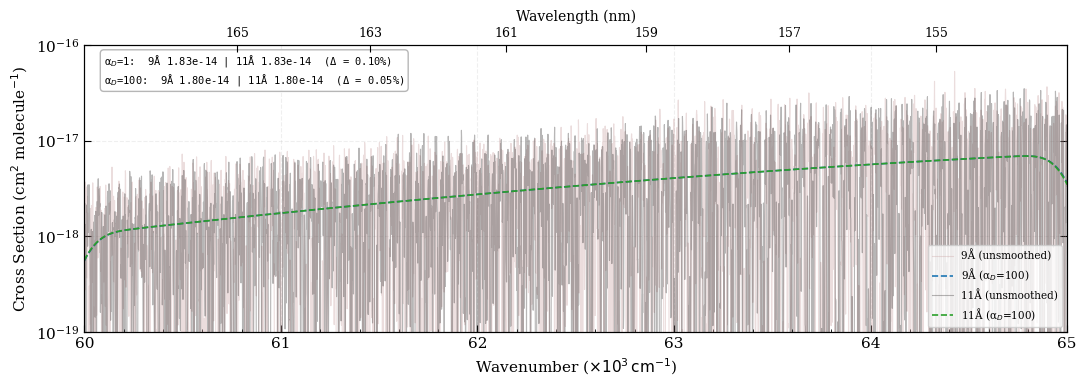

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FuncFormatter, FixedLocator
import matplotlib.ticker as mticker

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
})

FIGSIZE = (11, 4.0)
LW = 1.2
bin_low, bin_high = 60000, 65000

fig, ax = plt.subplots(figsize=FIGSIZE)

# ── storage for integrated values ──────────────────────────────────────────
integrated = {}   # key: (label, alpha_D) → float

for conn, label, base_color in zip(conns, labels, colors):
    if label == "10Å":
        continue

    continuum = conn.execute(f"""
        SELECT *
        FROM duo_oxygen1616_schumannrunge
        WHERE down_energy < 42025
          AND line_pos BETWEEN {bin_low} AND {bin_high}
    """).df()

    continuum['Intensity'] = (
        continuum['A']
        * (2 * continuum['up_J'] + 1)
        * np.exp(-(h * c * continuum['down_energy'] / (k_B * T)))
        / (8.0 * np.pi * c * continuum['line_pos']**2 * Q_T)
    )

    df = continuum.sort_values('line_pos')
    line_positions = df['line_pos'].values
    intensities    = df['Intensity'].values

    alpha_D_list  = [1, 100]
    nu_range      = np.linspace(bin_low, bin_high, 5000)
    cross_section_list = main(alpha_D_list, nu_range, line_positions, intensities, 10)

    for alpha_D, cs in zip(alpha_D_list, cross_section_list):
        integrated[(label, alpha_D)] = np.trapz(cs, nu_range)

        if alpha_D == 1:
            if label == "9Å":
            # grey sticks — semi-transparent so both R_max overlap visibly
                ax.plot(nu_range, cs,
                        linestyle='-', linewidth=0.8,
                        color="#C89F9F", alpha=0.35,
                        label=f"{label} (unsmoothed)")
            else:
                ax.plot(nu_range, cs,
                        linestyle='-', linewidth=0.8,
                        color="#322E2E", alpha=0.35,
                        label=f"{label} (unsmoothed)")
        else:
            ax.plot(nu_range, cs,
                    linestyle='--', linewidth=LW,
                    color=base_color, alpha=1.0,
                    label=f"{label} (α$_D$={alpha_D})")

# ── percent-difference annotations ────────────────────────────────────────
# Place a clean two-line annotation block in the upper-left
r_labels = [l for l in labels if l != "10Å"]

if len(r_labels) == 2:
    l0, l1 = r_labels[0], r_labels[1]
    annot_lines = []
    for alpha_D in [1, 100]:
        v0 = integrated[(l0, alpha_D)]
        v1 = integrated[(l1, alpha_D)]
        pct = abs(v0 - v1) / ((v0 + v1) / 2) * 100
        annot_lines.append(
            f"α$_D$={alpha_D}:  {l0} {v0:.2e} | {l1} {v1:.2e}  (Δ = {pct:.2f}%)"
        )

    ax.text(
        0.02, 0.97, "\n".join(annot_lines),
        transform=ax.transAxes,
        fontsize=7.5, va='top', ha='left',
        family='monospace',
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor='#aaaaaa', alpha=0.85)
    )

# ── x-axis: scale to ×10³ cm⁻¹ ───────────────────────────────────────────
ax.xaxis.set_major_locator(FixedLocator(np.arange(60000, 65001, 1000)))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}"))
ax.set_xlabel(r"Wavenumber ($\times 10^3\,\mathrm{cm}^{-1}$)")

# ── secondary top axis: wavelength in nm ──────────────────────────────────
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

# place nm ticks at round nm values within range
nm_ticks_nm  = np.arange(155, 168, 2)           # 155, 157, ..., 167 nm
nu_ticks     = 1e7 / nm_ticks_nm                 # convert to cm⁻¹
# keep only those within plot range
mask = (nu_ticks >= bin_low) & (nu_ticks <= bin_high)
nu_ticks    = nu_ticks[mask]
nm_ticks_nm = nm_ticks_nm[mask]

ax_top.set_xticks(nu_ticks)
ax_top.set_xticklabels([f"{v:.0f}" for v in nm_ticks_nm], fontsize=9)
ax_top.set_xlabel("Wavelength (nm)", fontsize=10)
ax_top.tick_params(which='major', direction='in', length=5)

# ── y-axis ─────────────────────────────────────────────────────────────────
ax.set_ylabel(r"Cross Section (cm$^{2}$ molecule$^{-1}$)")
ax.set_xlim(bin_low, bin_high)
ax.set_ylim(1e-19, 1e-16)
ax.set_yscale('log')

ax.legend(frameon=True, fontsize=7.5, loc='lower right')

ax.tick_params(which='major', direction='in', length=5, top=False, right=True)
ax.tick_params(which='minor', direction='in', length=2.5, top=False, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

ax.grid(True, ls='--', alpha=0.2)

plt.tight_layout()
plt.show()

while integrated cross section, in a dsmall wavenumber region on the high alpha D apears different, they're likely similar across a slightly wider ranger because of edge cases 

What's the point – well you can essentially choose a box wsize using jsut the highest energy level supported which in our case turned out to be blah --- ... using that and an energy level increase of 
